<a href="https://colab.research.google.com/github/FerneyPatino/ia/blob/main/Laboratorio_2_Modelos_Supervisados_con_UCI_AI4I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 7 — Laboratorio: comparación robusta de modelos supervisados con datos UCI

**Asignatura:** Inteligencia Aritificial

**Tema:** SVM, Árbol de Decisión, Random Forest y Gradient Boosting  
**Dataset:** [*AI4I 2020 Predictive Maintenance Dataset*](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset) — UCI Machine Learning Repository  
**Problema:** Clasificación binaria de fallas de máquina  
**Entregable:** Notebook ejecutado + archivos de resultados + conclusión técnica

---

## Propósito

Construir y comparar cuatro modelos supervisados sobre un problema de mantenimiento predictivo, pero evitando una comparación superficial basada únicamente en entrenar modelos y observar su `accuracy`.

En esta práctica deberá:

- auditar el dataset y detectar variables que no deberían utilizarse como predictores;
- reconocer el efecto del desbalance de clases;
- construir un modelo base de referencia;
- comparar SVM, Árbol de Decisión, Random Forest y Gradient Boosting;
- evaluar desempeño, estabilidad y sobreajuste;
- realizar ajuste de hiperparámetros;
- incorporar variables derivadas con sentido físico;
- analizar el costo de falsos negativos y falsos positivos;
- justificar una decisión final desde el punto de vista técnico y operativo.

> No se calificará únicamente cuál modelo obtiene el número más alto. Se calificará la calidad del procedimiento y de la justificación.


## 1. Contexto del problema

Una planta industrial quiere usar datos de operación para anticipar si una máquina se encuentra en una condición asociada con una falla.

El objetivo del laboratorio es construir un clasificador para predecir la variable **`Machine failure`**:

- `0`: operación sin falla.
- `1`: falla de máquina.

El conjunto de datos AI4I 2020 contiene 10 000 registros y fue diseñado para representar un escenario de mantenimiento predictivo industrial.

Fuente oficial:

https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

### Pregunta central

> ¿Cuál de los cuatro modelos estudiados permite detectar fallas con un compromiso adecuado entre desempeño, estabilidad, interpretabilidad y costo de error?


## 2. Reglas de la práctica

Debe comparar obligatoriamente:

1. SVM.
2. Árbol de Decisión.
3. Random Forest.
4. Gradient Boosting.

Además:

- utilice el mismo conjunto de entrenamiento, validación y prueba para todos los modelos;
- no utilice el conjunto de prueba para elegir hiperparámetros;
- documente cada decisión de preprocesamiento;
- no elimine una variable sin justificarlo;
- no agregue variables derivadas sin explicar qué representan;
- conserve una semilla aleatoria cuando corresponda para facilitar la reproducibilidad.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.inspection import permutation_importance

Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("reports").mkdir(parents=True, exist_ok=True)
Path("reports/figuras").mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42

print("Entorno preparado.")


Entorno preparado.


# Parte A — Adquisición y auditoría de los datos

## 3. Descarga del dataset

Descargue desde UCI el archivo `ai4i2020.csv` y guárdelo en:

```text
data/raw/ai4i2020.csv
```

No modifique manualmente el archivo antes de cargarlo.


In [5]:
# TODO 1
# Cargue el archivo original de UCI.

ruta = Path("data/raw/ai4i2020.csv")

df = pd.read_csv(ruta)

print("Dimensiones:", df.shape)
display(df.head())
print("\nColumnas exactas:")
for c in df.columns:
    print(repr(c))


Dimensiones: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1000,308.6000,1551,42.8000,0,0,0,0,0,0,0
1,2,L47181,L,298.2000,308.7000,1408,46.3000,3,0,0,0,0,0,0
2,3,L47182,L,298.1000,308.5000,1498,49.4000,5,0,0,0,0,0,0
3,4,L47183,L,298.2000,308.6000,1433,39.5000,7,0,0,0,0,0,0
4,5,L47184,L,298.2000,308.7000,1408,40.0000,9,0,0,0,0,0,0



Columnas exactas:
'UDI'
'Product ID'
'Type'
'Air temperature [K]'
'Process temperature [K]'
'Rotational speed [rpm]'
'Torque [Nm]'
'Tool wear [min]'
'Machine failure'
'TWF'
'HDF'
'PWF'
'OSF'
'RNF'


## 4. Auditoría inicial

Realice un diagnóstico del dataset antes de construir cualquier modelo.

Debe verificar como mínimo:

- número de filas y columnas;
- tipos de datos;
- valores faltantes;
- filas duplicadas;
- valores únicos de las variables categóricas;
- distribución de `Machine failure`;
- proporción de cada clase.

### Pregunta

Si un modelo predijera siempre la clase mayoritaria, ¿qué `accuracy` aproximado esperaría obtener?

No entrene todavía ningún modelo para responder esta pregunta.


In [6]:
# TODO 2
# Realice la auditoría inicial.

print("=== Tipos de datos ===")
df.info()

print("\n=== Valores faltantes por columna ===")
print(df.isna().sum())

print("\n=== Filas duplicadas ===")
print("Filas duplicadas (completas):", df.duplicated().sum())
print("UDI duplicados:", df["UDI"].duplicated().sum())
print("Product ID duplicados:", df["Product ID"].duplicated().sum())

print("\n=== Valores únicos de variables categóricas ===")
for col in ["Type", "Product ID"]:
    print(f"{col}: {df[col].nunique()} valores únicos")
print(df["Type"].value_counts())

print("\n=== Distribución de Machine failure ===")
conteo = df["Machine failure"].value_counts()
proporcion = df["Machine failure"].value_counts(normalize=True)
print(pd.DataFrame({"conteo": conteo, "proporcion": proporcion}))

print("\n=== Accuracy esperado de un clasificador que siempre predice la clase mayoritaria ===")
print(f"{proporcion.max():.4f}")

print("\n=== Relación entre Machine failure y los modos de falla ===")
modos = ["TWF", "HDF", "PWF", "OSF", "RNF"]
alguna = (df[modos].sum(axis=1) > 0).astype(int)
print(pd.crosstab(df["Machine failure"], alguna,
                  rownames=["Machine failure"], colnames=["Algún modo de falla = 1"]))


=== Tipos de datos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtype

## 5. Auditoría de variables: ¿todas las columnas pueden entrar al modelo?

Clasifique cada columna en una de estas categorías:

- identificador;
- predictor válido;
- variable objetivo;
- variable potencialmente problemática;
- variable que podría producir fuga de información (*data leakage*).

Complete una tabla como la siguiente.

| Variable | Rol propuesto | ¿Usarla como predictor? | Justificación |
|---|---|---:|---|
| ... | ... | Sí/No | ... |

### Reto

El archivo original contiene columnas cuyo uso podría hacer que el modelo conozca indirectamente el resultado que intenta predecir.

Identifíquelas y explique por qué su inclusión invalidaría la comparación.


In [7]:
# TODO 3
# Construya una tabla de auditoría de variables.

auditoria_variables = pd.DataFrame([
    {"variable": "UDI",
     "rol_propuesto": "Identificador",
     "usar_como_predictor": "No",
     "justificacion": "Índice secuencial de fila sin significado físico; el modelo podría memorizar posiciones y no generalizaría."},
    {"variable": "Product ID",
     "rol_propuesto": "Identificador",
     "usar_como_predictor": "No",
     "justificacion": "Identificador único de alta cardinalidad; su letra inicial ya está en Type y el resto es un número de serie sin información causal."},
    {"variable": "Type",
     "rol_propuesto": "Predictor válido (categórico)",
     "usar_como_predictor": "Sí",
     "justificacion": "Calidad del producto (L/M/H), conocida antes de la operación; puede modular la tolerancia a la carga."},
    {"variable": "Air temperature [K]",
     "rol_propuesto": "Predictor válido (numérico)",
     "usar_como_predictor": "Sí",
     "justificacion": "Medición de sensor previa al evento de falla."},
    {"variable": "Process temperature [K]",
     "rol_propuesto": "Predictor válido (numérico)",
     "usar_como_predictor": "Sí",
     "justificacion": "Medición de sensor; permite construir la diferencia de temperatura con el ambiente."},
    {"variable": "Rotational speed [rpm]",
     "rol_propuesto": "Predictor válido (numérico)",
     "usar_como_predictor": "Sí",
     "justificacion": "Medición de sensor; junto con el torque determina la potencia mecánica."},
    {"variable": "Torque [Nm]",
     "rol_propuesto": "Predictor válido (numérico)",
     "usar_como_predictor": "Sí",
     "justificacion": "Medición de sensor; indicador de sobrecarga."},
    {"variable": "Tool wear [min]",
     "rol_propuesto": "Predictor válido (numérico)",
     "usar_como_predictor": "Sí",
     "justificacion": "Tiempo acumulado de uso de la herramienta; indicador de desgaste conocido antes de la falla."},
    {"variable": "Machine failure",
     "rol_propuesto": "Variable objetivo",
     "usar_como_predictor": "No",
     "justificacion": "Es la etiqueta a predecir (0 = sin falla, 1 = falla)."},
    {"variable": "TWF",
     "rol_propuesto": "Fuga de información",
     "usar_como_predictor": "No",
     "justificacion": "Falla por desgaste de herramienta: es un subtipo del evento a predecir. Su valor 1 implica Machine failure = 1."},
    {"variable": "HDF",
     "rol_propuesto": "Fuga de información",
     "usar_como_predictor": "No",
     "justificacion": "Falla por disipación de calor: subtipo del evento objetivo, registrado después de ocurrida la falla."},
    {"variable": "PWF",
     "rol_propuesto": "Fuga de información",
     "usar_como_predictor": "No",
     "justificacion": "Falla de potencia: subtipo del evento objetivo."},
    {"variable": "OSF",
     "rol_propuesto": "Fuga de información",
     "usar_como_predictor": "No",
     "justificacion": "Falla por sobreesfuerzo: subtipo del evento objetivo."},
    {"variable": "RNF",
     "rol_propuesto": "Fuga de información",
     "usar_como_predictor": "No",
     "justificacion": "Falla aleatoria: subtipo del evento objetivo; además es ruido por definición (no depende de las mediciones)."},
])

auditoria_variables.to_csv("reports/auditoria_variables.csv", index=False)
auditoria_variables


,variable,rol_propuesto,usar_como_predictor,justificacion
0,UDI,Identificador,No,Índice secuencial de fila sin significado físi...
1,Product ID,Identificador,No,Identificador único de alta cardinalidad; su l...
2,Type,Predictor válido (categórico),Sí,"Calidad del producto (L/M/H), conocida antes d..."
3,Air temperature [K],Predictor válido (numérico),Sí,Medición de sensor previa al evento de falla.
4,Process temperature [K],Predictor válido (numérico),Sí,Medición de sensor; permite construir la difer...
5,Rotational speed [rpm],Predictor válido (numérico),Sí,Medición de sensor; junto con el torque determ...
6,Torque [Nm],Predictor válido (numérico),Sí,Medición de sensor; indicador de sobrecarga.
7,Tool wear [min],Predictor válido (numérico),Sí,Tiempo acumulado de uso de la herramienta; ind...
8,Machine failure,Variable objetivo,No,"Es la etiqueta a predecir (0 = sin falla, 1 = ..."
9,TWF,Fuga de información,No,Falla por desgaste de herramienta: es un subti...


# Parte B — Formulación experimental

## 6. Formule el problema

Complete:

- Contexto:
- Pregunta de IA:
- Tipo de problema:
- Variable objetivo:
- Clase de mayor interés operativo:
- Error más costoso: falso positivo o falso negativo:
- Razón:
- Métricas que utilizará:
- Métrica que **no** debería utilizarse sola:
- Criterio preliminar para seleccionar un modelo:


**Respuesta del grupo**

- **Contexto:** Una planta industrial busca anticipar, a partir de datos de operación (temperaturas, velocidad de rotación, torque y desgaste de herramienta), si una máquina se encuentra en una condición asociada con una falla, con el fin de programar mantenimiento antes de que ocurra una parada no planificada.
- **Pregunta de IA:** ¿Cuál de los cuatro modelos supervisados (SVM, Árbol de Decisión, Random Forest y Gradient Boosting) detecta fallas con un compromiso adecuado entre desempeño, estabilidad, interpretabilidad y costo de error?
- **Tipo de problema:** Clasificación supervisada binaria, con desbalance severo de clases (aproximadamente 3.4 % de fallas).
- **Variable objetivo:** `Machine failure` (0 = operación sin falla; 1 = falla).
- **Clase de mayor interés operativo:** La clase positiva (`1`, falla), por ser la que debe anticiparse.
- **Error más costoso:** Falso negativo.
- **Razón:** Un falso negativo implica no detectar una falla real, con riesgo de parada no planificada, daño del equipo y pérdida de producción. Un falso positivo genera una inspección innecesaria, cuyo costo es considerablemente menor. Por ello se asume una relación de costos de 10 a 1 (FN frente a FP).
- **Métricas:** Recall, precision y F1 de la clase positiva, PR-AUC, ROC-AUC, balanced accuracy, conteo de FP y FN, y costo operativo. Como complemento, F1 macro y validación cruzada estratificada para evaluar estabilidad.
- **Métrica insuficiente por sí sola:** Accuracy, porque un modelo que siempre predice "sin falla" alcanzaría cerca de 96.6 % sin detectar ninguna falla.
- **Criterio preliminar de selección:** Se seleccionará el modelo con mejor equilibrio entre recall, F1 y PR-AUC de la clase positiva en validación, con baja desviación estándar en validación cruzada, brecha train-validación reducida y menor costo operativo. En caso de desempeño similar, se preferirá el modelo más interpretable y de menor complejidad.


## 7. Defina `X` e `y`

Construya el conjunto de predictores después de la auditoría.

No incluya identificadores ni variables que revelen directa o indirectamente la condición de falla.


In [8]:
# Variable objetivo
variable_objetivo = "Machine failure"

# Variables predictoras válidas después de la auditoría
variables_predictoras = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Definición de X e y
X = df[variables_predictoras].copy()
y = df[variable_objetivo].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nVariables predictoras:")
print(variables_predictoras)

print("\nVariable objetivo:")
print(variable_objetivo)

Dimensiones de X: (10000, 6)
Dimensiones de y: (10000,)

Variables predictoras:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Variable objetivo:
Machine failure


## 8. Separación entrenamiento / validación / prueba

Utilice una división estratificada:

- 60 % entrenamiento;
- 20 % validación;
- 20 % prueba.

El conjunto de:

- **entrenamiento** se utiliza para ajustar modelos;
- **validación** se utiliza para comparar decisiones y umbrales;
- **prueba** permanece intacto hasta la evaluación final.

### Pregunta

¿Por qué sería metodológicamente incorrecto ajustar repetidamente el modelo mirando el resultado del conjunto de prueba?


In [9]:
# TODO 5
# Separación 60 % entrenamiento, 20 % validación y 20 % prueba

# 1. Separar 20 % para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# 2. Del 80 % restante, separar 25 % para validación
#    25 % de 80 % = 20 % del total
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# Verificar dimensiones
print("=== Dimensiones de los conjuntos ===")
print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:   ", X_val.shape, y_val.shape)
print("Prueba:       ", X_test.shape, y_test.shape)

# Verificar proporción de clases
print("\n=== Distribución de Machine failure ===")

distribucion = pd.DataFrame({
    "Entrenamiento": y_train.value_counts(normalize=True),
    "Validación": y_val.value_counts(normalize=True),
    "Prueba": y_test.value_counts(normalize=True)
})

print(distribucion)

# Cantidad de registros por clase
print("\n=== Cantidad de registros por clase ===")

conteos = pd.DataFrame({
    "Entrenamiento": y_train.value_counts(),
    "Validación": y_val.value_counts(),
    "Prueba": y_test.value_counts()
})

print(conteos)


print(
    "Porque el conjunto de prueba debe representar datos que el modelo no ha utilizado durante el proceso de toma de decisiones.\n"
    "Si se consulta repetidamente el desempeño sobre prueba para modificar hiperparámetros, características, modelo o umbral,\n"
    "indirectamente se está utilizando la información del conjunto de prueba para optimizar el modelo.\n"
    "Esto produce una estimación demasiado optimista del desempeño y reduce la capacidad del conjunto de prueba\n"
    "para representar el comportamiento del modelo ante datos realmente no vistos.\n"
    "Por esta razón, en este laboratorio el conjunto de validación se utiliza para comparar modelos y seleccionar decisiones,\n"
    "mientras que el conjunto de prueba se mantiene intacto hasta la evaluación final."
)

=== Dimensiones de los conjuntos ===
Entrenamiento: (6000, 6) (6000,)
Validación:    (2000, 6) (2000,)
Prueba:        (2000, 6) (2000,)

=== Distribución de Machine failure ===
                 Entrenamiento  Validación  Prueba
Machine failure                                   
0                       0.9662      0.9660  0.9660
1                       0.0338      0.0340  0.0340

=== Cantidad de registros por clase ===
                 Entrenamiento  Validación  Prueba
Machine failure                                   
0                         5797        1932    1932
1                          203          68      68
Porque el conjunto de prueba debe representar datos que el modelo no ha utilizado durante el proceso de toma de decisiones.
Si se consulta repetidamente el desempeño sobre prueba para modificar hiperparámetros, características, modelo o umbral,
indirectamente se está utilizando la información del conjunto de prueba para optimizar el modelo.
Esto produce una estimación dem

# Parte C — Línea base y preprocesamiento

## 9. Modelo ingenuo de referencia

Entrene un `DummyClassifier(strategy="most_frequent")`.

Compare:

- accuracy;
- balanced accuracy;
- precision;
- recall;
- F1 de la clase positiva.

### Pregunta

Explique por qué un modelo puede obtener un `accuracy` alto y, al mismo tiempo, ser inútil para mantenimiento predictivo.


In [10]:
# TODO 6
# Modelo ingenuo de referencia

dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

# Entrenamiento únicamente con el conjunto de entrenamiento
dummy.fit(X_train, y_train)

# Predicciones sobre validación
y_pred_dummy = dummy.predict(X_val)

# Cálculo de métricas
accuracy_dummy = accuracy_score(y_val, y_pred_dummy)
balanced_accuracy_dummy = balanced_accuracy_score(y_val, y_pred_dummy)
precision_dummy = precision_score(y_val, y_pred_dummy, zero_division=0)
recall_dummy = recall_score(y_val, y_pred_dummy, zero_division=0)
f1_dummy = f1_score(y_val, y_pred_dummy, zero_division=0)

print("=== Modelo ingenuo de referencia ===")
print(f"Accuracy:            {accuracy_dummy:.4f}")
print(f"Balanced Accuracy:   {balanced_accuracy_dummy:.4f}")
print(f"Precision:           {precision_dummy:.4f}")
print(f"Recall:              {recall_dummy:.4f}")
print(f"F1:                  {f1_dummy:.4f}")


print(
    "El accuracy puede ser alto debido al fuerte desbalance de clases presente en el dataset.\n"
    "En este caso, aproximadamente el 96.61 % de los registros corresponden a operaciones sin falla, mientras que solo el 3.39 % corresponden a fallas.\n"
    "Por lo tanto, un modelo que siempre prediga la clase mayoritaria puede alcanzar cerca de 96.6 % de accuracy sin detectar ninguna falla.\n"
    "Esto se refleja en un recall y un F1 de la clase positiva iguales a cero.\n"
    "Por esta razón, el accuracy no es suficiente para evaluar un sistema de mantenimiento predictivo, donde detectar correctamente la clase de falla es especialmente importante."
)

=== Modelo ingenuo de referencia ===
Accuracy:            0.9660
Balanced Accuracy:   0.5000
Precision:           0.0000
Recall:              0.0000
F1:                  0.0000
El accuracy puede ser alto debido al fuerte desbalance de clases presente en el dataset.
En este caso, aproximadamente el 96.61 % de los registros corresponden a operaciones sin falla, mientras que solo el 3.39 % corresponden a fallas.
Por lo tanto, un modelo que siempre prediga la clase mayoritaria puede alcanzar cerca de 96.6 % de accuracy sin detectar ninguna falla.
Esto se refleja en un recall y un F1 de la clase positiva iguales a cero.
Por esta razón, el accuracy no es suficiente para evaluar un sistema de mantenimiento predictivo, donde detectar correctamente la clase de falla es especialmente importante.


## 10. Preprocesador común

Construya un `ColumnTransformer`.

Para variables numéricas:

1. imputación por mediana;
2. escalado con `StandardScaler`.

Para variables categóricas:

1. imputación por moda;
2. `OneHotEncoder(handle_unknown="ignore")`.

Aunque el dataset oficial no debería contener faltantes, el pipeline debe ser capaz de manejar datos faltantes.


In [11]:
# TODO 7
# Identificar variables numéricas y categóricas

columnas_numericas = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

columnas_categoricas = [
    "Type"
]

# Preprocesamiento para variables numéricas
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocesamiento para variables categóricas
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

# Preprocesador común
preprocesador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

print("\nPreprocesador creado correctamente.")


Variables numéricas:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Variables categóricas:
['Type']

Preprocesador creado correctamente.


# Parte D — Comparación inicial de los cuatro modelos

## 11. Defina los modelos iniciales

Utilice una configuración razonable pero todavía sin búsqueda exhaustiva.

Debe mantener los cuatro modelos obligatorios.

> Para SVM utilice `probability=True`, porque más adelante se evaluarán probabilidades y umbrales.


In [12]:
# TODO 8
# Definir los cuatro modelos

modelos = {
    "SVM": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),

    "Arbol de decision": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

modelos


{'SVM': SVC(probability=True, random_state=42),
 'Arbol de decision': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

## 12. Función de evaluación

Cree una función que reciba:

- modelo;
- `X`;
- `y`;

y retorne:

- accuracy;
- balanced accuracy;
- precision;
- recall;
- F1;
- ROC-AUC;
- PR-AUC (`average_precision_score`);
- cantidad de falsos positivos;
- cantidad de falsos negativos.

La función debe usar probabilidades cuando estén disponibles.


In [13]:
# TODO 9
# Función reutilizable para evaluar clasificadores

def evaluar_clasificador(modelo, X, y):
    """
    Retorna un diccionario con métricas de clasificación.
    """

    # Predicciones
    y_pred = modelo.predict(X)

    # Probabilidades para calcular ROC-AUC y PR-AUC
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X)[:, 1]
    elif hasattr(modelo, "decision_function"):
        y_prob = modelo.decision_function(X)
    else:
        y_prob = None

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(
        y,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # Métricas
    resultados = {
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, y_prob) if y_prob is not None else np.nan,
        "PR_AUC": average_precision_score(y, y_prob) if y_prob is not None else np.nan,
        "FP": fp,
        "FN": fn
    }

    return resultados

## 13. Entrenamiento inicial

Entrene los cuatro modelos usando exactamente el mismo conjunto de entrenamiento.

Evalúe primero sobre validación.

Construya una tabla comparativa y ordénela según un criterio que considere adecuado.

### Restricción

No seleccione un modelo únicamente porque tenga el mayor `accuracy`.


In [50]:
# TODO 10
# Entrenar y evaluar los cuatro modelos

resultados_iniciales = []
pipelines_iniciales = {}

for nombre, modelo in modelos.items():

    # Pipeline común: preprocesamiento + modelo
    pipeline = Pipeline(steps=[
        ("preprocesador", preprocesador),
        ("modelo", modelo)
    ])

    # Entrenamiento
    pipeline.fit(X_train, y_train)

    # Guardar pipeline entrenado
    pipelines_iniciales[nombre] = pipeline

    # Evaluación sobre entrenamiento
    metricas_train = evaluar_clasificador(
        pipeline,
        X_train,
        y_train
    )

    # Evaluación sobre validación
    metricas_val = evaluar_clasificador(
        pipeline,
        X_val,
        y_val
    )

    # Guardar resultados
    resultados_iniciales.append({
        "modelo": nombre,

        "accuracy_train": metricas_train["accuracy"],
        "balanced_accuracy_train": metricas_train["balanced_accuracy"],
        "precision_train": metricas_train["precision"],
        "recall_train": metricas_train["recall"],
        "f1_train": metricas_train["f1"],
        "ROC_AUC_train": metricas_train["ROC_AUC"],
        "PR_AUC_train": metricas_train["PR_AUC"],
        "FP_train": metricas_train["FP"],
        "FN_train": metricas_train["FN_train"] if "FN_train" in metricas_train else metricas_train["FN"],

        "accuracy_val": metricas_val["accuracy"],
        "balanced_accuracy_val": metricas_val["balanced_accuracy"],
        "precision_val": metricas_val["precision"],
        "recall_val": metricas_val["recall"],
        "f1_val": metricas_val["f1"],
        "ROC_AUC_val": metricas_val["ROC_AUC"],
        "PR_AUC_val": metricas_val["PR_AUC"],
        "FP_val": metricas_val["FP"],
        "FN_val": metricas_val["FN"]
    })

# Convertir resultados a DataFrame
df_resultados_iniciales = pd.DataFrame(resultados_iniciales)

# GUARDAR CSV
df_resultados_iniciales.to_csv(
"reports/resultados_modelos_iniciales.csv",
index=False
)

# Mostrar tabla
df_resultados_iniciales


,modelo,accuracy_train,balanced_accuracy_train,precision_train,recall_train,f1_train,ROC_AUC_train,PR_AUC_train,FP_train,FN_train,accuracy_val,balanced_accuracy_val,precision_val,recall_val,f1_val,ROC_AUC_val,PR_AUC_val,FP_val,FN_val
0,SVM,0.9760,0.6572,0.9275,0.3153,0.4706,0.9699,0.7655,5,139,0.9740,0.6318,0.9000,0.2647,0.4091,0.9224,0.6321,2,50
1,Arbol de decision,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0,0,0.9735,0.7806,0.6190,0.5735,0.5954,0.7806,0.3695,24,29
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0,0,0.9820,0.7495,0.9444,0.5000,0.6538,0.9669,0.7487,2,34
3,Gradient Boosting,0.9922,0.8890,0.9875,0.7783,0.8705,0.9867,0.9415,2,45,0.9825,0.8065,0.8235,0.6176,0.7059,0.9770,0.7460,9,26


## 14. Sobreajuste

Para cada modelo, calcule por lo menos:

- diferencia F1 entre entrenamiento y validación;
- diferencia recall entre entrenamiento y validación.

Interprete las diferencias.

### Preguntas

1. ¿Qué modelo parece sobreajustarse más?
2. ¿Qué modelo parece subajustarse?
3. ¿Un resultado perfecto en entrenamiento sería necesariamente una buena señal?


In [15]:
# TODO 11
# Calcular brechas entre entrenamiento y validación

df_resultados_iniciales["brecha_f1"] = (
    df_resultados_iniciales["f1_train"]
    - df_resultados_iniciales["f1_val"]
)

df_resultados_iniciales["brecha_recall"] = (
    df_resultados_iniciales["recall_train"]
    - df_resultados_iniciales["recall_val"]
)

# Mostrar las columnas relevantes
df_resultados_iniciales[
    [
        "modelo",
        "f1_train",
        "f1_val",
        "brecha_f1",
        "recall_train",
        "recall_val",
        "brecha_recall"
    ]
]



,modelo,f1_train,f1_val,brecha_f1,recall_train,recall_val,brecha_recall
0,SVM,0.4706,0.4091,0.0615,0.3153,0.2647,0.0506
1,Arbol de decision,1.0000,0.5954,0.4046,1.0000,0.5735,0.4265
2,Random Forest,1.0000,0.6538,0.3462,1.0000,0.5000,0.5000
3,Gradient Boosting,0.8705,0.7059,0.1646,0.7783,0.6176,0.1607


In [46]:
print(
    "¿Qué modelo parece sobreajustarse más?\n"
    "• El Árbol de Decisión presenta el mayor sobreajuste (brecha F1\n"
    "  de 0.4046 y recall de 0.4265). Aprende muy bien los datos de\n"
    "  entrenamiento, pero pierde capacidad de generalización al\n"
    "  enfrentarse a datos no vistos.\n\n"
    "¿Qué modelo parece subajustarse?\n"
    "• El SVM subajusta inicialmente con un desempeño bajo en ambos\n"
    "  conjuntos, registrando los valores más bajos de recall (0.2647)\n"
    "  y F1 (0.4091). Esto evidencia dificultad para capturar los patrones\n"
    "  (aunque mejora tras el ajuste de hiperparámetros).\n\n"
    "¿Un resultado perfecto en entrenamiento sería buena señal?\n"
    "• No. Es una clara señal de sobreajuste. El Árbol de Decisión logra\n"
    "  desempeño perfecto en entrenamiento pero cae en validación. Lo\n"
    "  importante es mantener un rendimiento alto en datos no vistos."
)

¿Qué modelo parece sobreajustarse más?
• El Árbol de Decisión presenta el mayor sobreajuste (brecha F1
  de 0.4046 y recall de 0.4265). Aprende muy bien los datos de
  entrenamiento, pero pierde capacidad de generalización al
  enfrentarse a datos no vistos.

¿Qué modelo parece subajustarse?
• El SVM subajusta inicialmente con un desempeño bajo en ambos
  conjuntos, registrando los valores más bajos de recall (0.2647)
  y F1 (0.4091). Esto evidencia dificultad para capturar los patrones
  (aunque mejora tras el ajuste de hiperparámetros).

¿Un resultado perfecto en entrenamiento sería buena señal?
• No. Es una clara señal de sobreajuste. El Árbol de Decisión logra
  desempeño perfecto en entrenamiento pero cae en validación. Lo
  importante es mantener un rendimiento alto en datos no vistos.


## 15. Matrices de confusión

Genere una matriz de confusión para cada modelo sobre validación.

No se limite a mostrar las matrices. Para cada modelo indique:

- falsos positivos;
- falsos negativos;
- cuál de los dos errores sería más problemático en este contexto.


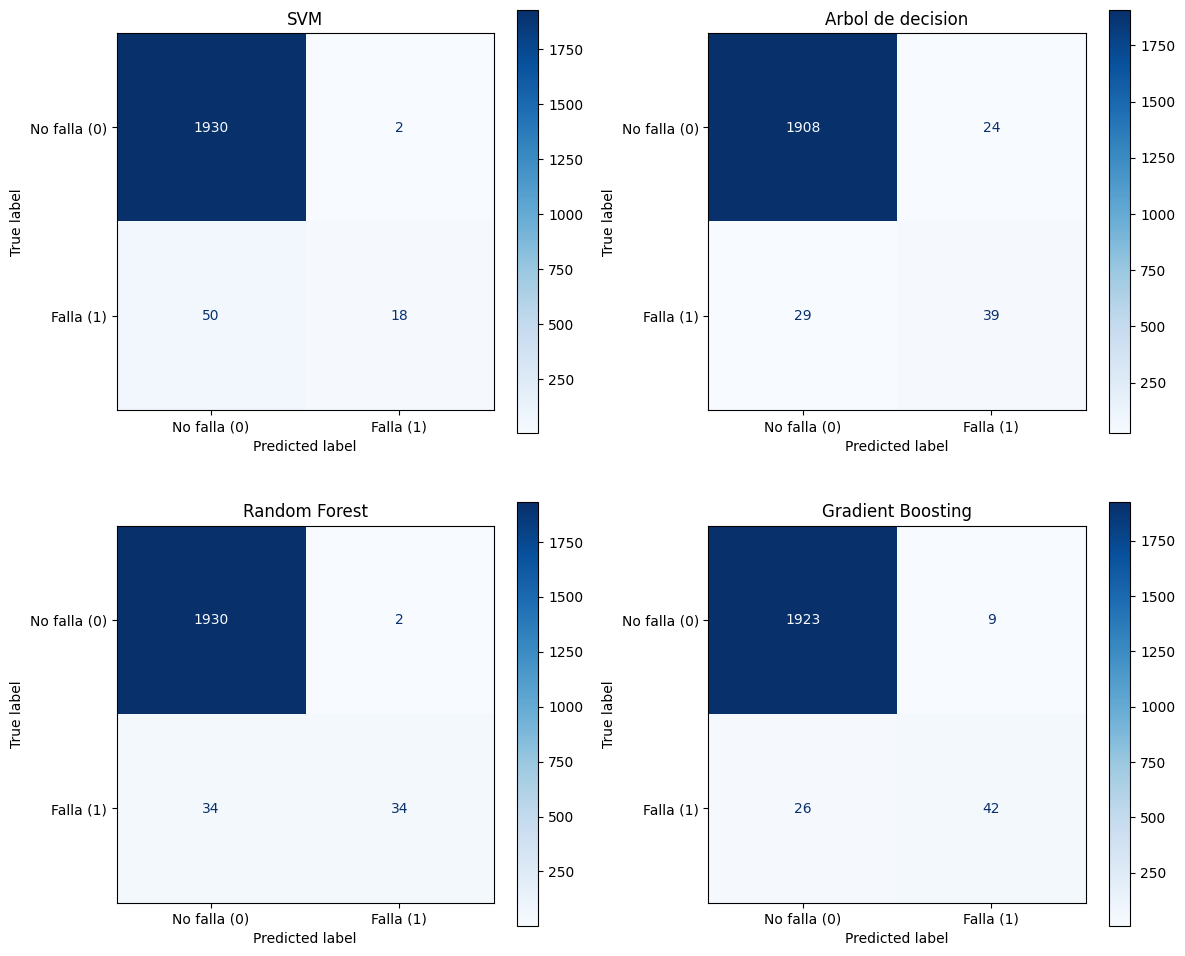

In [17]:
# TODO 12
# Matrices de confusión sobre validación

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (nombre, pipeline) in zip(axes, pipelines_iniciales.items()):

    y_pred = pipeline.predict(X_val)

    cm = confusion_matrix(
        y_val,
        y_pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No falla (0)", "Falla (1)"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        cmap="Blues"
    )

    ax.set_title(nombre)

plt.tight_layout()
plt.show()


In [18]:
for nombre, pipeline in pipelines_iniciales.items():
    y_pred = pipeline.predict(X_val)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred, labels=[0, 1]).ravel()
    print(f"{nombre}: FP = {fp}, FN = {fn} "
          f"(se pierde el {fn/(fn+tp):.0%} de las fallas reales), "
          f"costo = {10*fn + fp}")

print(
    "\nEl error más problemático en este contexto es el falso negativo: no detectar una falla real\n"
    "implica parada no planificada, daño del equipo y pérdida de producción, mientras que un falso\n"
    "positivo solo genera una inspección innecesaria (relación de costos asumida 10 a 1)."
)

SVM: FP = 2, FN = 50 (se pierde el 74% de las fallas reales), costo = 502
Arbol de decision: FP = 24, FN = 29 (se pierde el 43% de las fallas reales), costo = 314
Random Forest: FP = 2, FN = 34 (se pierde el 50% de las fallas reales), costo = 342
Gradient Boosting: FP = 9, FN = 26 (se pierde el 38% de las fallas reales), costo = 269

El error más problemático en este contexto es el falso negativo: no detectar una falla real
implica parada no planificada, daño del equipo y pérdida de producción, mientras que un falso
positivo solo genera una inspección innecesaria (relación de costos asumida 10 a 1).


## 16. Compare antes y después del ajuste

Evalúe los modelos ajustados sobre validación y compare con las versiones iniciales.

Responda:

1. ¿Todos los modelos mejoraron?
2. ¿Cuál tuvo la mayor mejora?
3. ¿Alguno perdió desempeño fuera del entrenamiento?
4. ¿La búsqueda cambió el modelo que usted habría seleccionado inicialmente?


In [19]:
# Ajuste de hiperparámetros: RandomizedSearchCV con CV estratificada SOLO sobre X_train
# (validación y prueba no se tocan durante la búsqueda)
import time
from sklearn.base import clone
from scipy.stats import randint, uniform, loguniform

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

espacios = {
    "SVM": {
        "modelo__C": loguniform(1e-1, 1e2),
        "modelo__gamma": loguniform(1e-3, 1e0),
        "modelo__class_weight": [None, "balanced"],
    },
    "Arbol de decision": {
        "modelo__max_depth": [3, 4, 5, 6, 8, 10, None],
        "modelo__min_samples_leaf": randint(1, 30),
        "modelo__min_samples_split": randint(2, 40),
        "modelo__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "modelo__n_estimators": randint(100, 400),
        "modelo__max_depth": [5, 8, 12, None],
        "modelo__min_samples_leaf": randint(1, 15),
        "modelo__max_features": ["sqrt", "log2", 0.5],
        "modelo__class_weight": [None, "balanced", "balanced_subsample"],
    },
    "Gradient Boosting": {
        "modelo__n_estimators": randint(100, 400),
        "modelo__learning_rate": loguniform(0.01, 0.3),
        "modelo__max_depth": randint(2, 5),
        "modelo__subsample": uniform(0.6, 0.4),
        "modelo__min_samples_leaf": randint(1, 20),
    },
}

scoring = {"pr_auc": "average_precision", "f1": "f1", "recall": "recall"}

pipelines_ajustados = {}
filas_busqueda = []

for nombre, espacio in espacios.items():
    pipe = clone(pipelines_iniciales[nombre])   # mismo preprocesador + modelo base
    t0 = time.time()

    busqueda = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=espacio,
        n_iter=20,
        scoring=scoring,
        refit="pr_auc",          # criterio de selección: PR-AUC (independiente del umbral)
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    busqueda.fit(X_train, y_train)
    seg = time.time() - t0

    pipelines_ajustados[nombre] = busqueda.best_estimator_
    i = busqueda.best_index_
    filas_busqueda.append({
        "modelo": nombre,
        "mejores_parametros": busqueda.best_params_,
        "cv_pr_auc_media": busqueda.cv_results_["mean_test_pr_auc"][i],
        "cv_pr_auc_std": busqueda.cv_results_["std_test_pr_auc"][i],
        "cv_f1_media": busqueda.cv_results_["mean_test_f1"][i],
        "cv_recall_media": busqueda.cv_results_["mean_test_recall"][i],
        "segundos_busqueda": seg,
    })
    print(f"{nombre}: listo en {seg:.0f}s")

df_busqueda = pd.DataFrame(filas_busqueda)
df_busqueda.to_csv("reports/resultados_busqueda_hiperparametros.csv", index=False)
df_busqueda


SVM: listo en 159s
Arbol de decision: listo en 5s
Random Forest: listo en 145s
Gradient Boosting: listo en 144s


,modelo,mejores_parametros,cv_pr_auc_media,cv_pr_auc_std,cv_f1_media,cv_recall_media,segundos_busqueda
0,SVM,"{'modelo__C': 83.41930294140772, 'modelo__clas...",0.6880,0.0957,0.5139,0.3793,159.2402
1,Arbol de decision,"{'modelo__class_weight': None, 'modelo__max_de...",0.6558,0.0822,0.5939,0.5182,5.4355
2,Random Forest,"{'modelo__class_weight': None, 'modelo__max_de...",0.7625,0.0676,0.6548,0.5277,144.9870
3,Gradient Boosting,"{'modelo__learning_rate': 0.02545642421255076,...",0.7896,0.0533,0.6934,0.5916,143.8536


In [20]:
# TODO 13
# Comparación antes/después del ajuste, ambos evaluados sobre VALIDACIÓN

COSTO_FN, COSTO_FP = 10, 1
filas = []

for nombre in pipelines_iniciales:
    antes  = evaluar_clasificador(pipelines_iniciales[nombre], X_val, y_val)
    despues = evaluar_clasificador(pipelines_ajustados[nombre], X_val, y_val)
    f1_train_despues = evaluar_clasificador(pipelines_ajustados[nombre], X_train, y_train)["f1"]

    fila = {"modelo": nombre}
    for m in ["f1", "recall", "precision", "PR_AUC", "ROC_AUC", "FP", "FN"]:
        fila[f"{m}_antes"] = antes[m]
        fila[f"{m}_despues"] = despues[m]
        fila[f"delta_{m}"] = despues[m] - antes[m]

    fila["costo_antes"]   = COSTO_FN * antes["FN"]   + COSTO_FP * antes["FP"]
    fila["costo_despues"] = COSTO_FN * despues["FN"] + COSTO_FP * despues["FP"]
    fila["delta_costo"]   = fila["costo_despues"] - fila["costo_antes"]

    # ¿el ajuste redujo o aumentó el sobreajuste?
    fila["brecha_f1_antes"]   = df_resultados_iniciales.loc[
        df_resultados_iniciales["modelo"] == nombre, "brecha_f1"].values[0]
    fila["brecha_f1_despues"] = f1_train_despues - despues["f1"]
    filas.append(fila)

df_antes_despues = pd.DataFrame(filas)
df_antes_despues.to_csv("reports/comparacion_antes_despues_ajuste.csv", index=False)

# Vista compacta
vista = df_antes_despues[[
    "modelo", "f1_antes", "f1_despues", "delta_f1",
    "recall_antes", "recall_despues",
    "PR_AUC_antes", "PR_AUC_despues", "delta_PR_AUC",
    "FN_antes", "FN_despues", "FP_antes", "FP_despues",
    "costo_antes", "costo_despues", "brecha_f1_antes", "brecha_f1_despues"
]]
display(vista)

# Apoyo para responder las 4 preguntas (con datos, no de memoria)
print("\n1. ¿Todos mejoraron? (delta_f1 y delta_PR_AUC > 0, delta_costo < 0)")
print(df_antes_despues[["modelo", "delta_f1", "delta_PR_AUC", "delta_costo"]]
      .assign(mejoro=lambda d: (d.delta_f1 > 0) & (d.delta_PR_AUC > 0) & (d.delta_costo < 0)))

print("\n2. Mayor mejora en F1:", df_antes_despues.loc[df_antes_despues["delta_f1"].idxmax(), "modelo"])
print("   Mayor mejora en PR-AUC:", df_antes_despues.loc[df_antes_despues["delta_PR_AUC"].idxmax(), "modelo"])
print("   Mayor reducción de costo:", df_antes_despues.loc[df_antes_despues["delta_costo"].idxmin(), "modelo"])

print("\n3. Modelos que perdieron desempeño en validación:")
peor = df_antes_despues[(df_antes_despues.delta_f1 < 0) | (df_antes_despues.delta_PR_AUC < 0)]
print(peor[["modelo", "delta_f1", "delta_PR_AUC"]] if len(peor) else "Ninguno")

print("\n4. Mejor modelo por F1 / PR-AUC / costo (validación)")
for etiqueta, col, mejor in [("Antes (F1)", "f1_antes", "max"), ("Después (F1)", "f1_despues", "max"),
                             ("Antes (PR-AUC)", "PR_AUC_antes", "max"), ("Después (PR-AUC)", "PR_AUC_despues", "max"),
                             ("Antes (costo)", "costo_antes", "min"), ("Después (costo)", "costo_despues", "min")]:
    idx = getattr(df_antes_despues[col], "idx" + mejor)()
    print(f"  {etiqueta:18s}: {df_antes_despues.loc[idx, 'modelo']}")

,modelo,f1_antes,f1_despues,delta_f1,recall_antes,recall_despues,PR_AUC_antes,PR_AUC_despues,delta_PR_AUC,FN_antes,FN_despues,FP_antes,FP_despues,costo_antes,costo_despues,brecha_f1_antes,brecha_f1_despues
0,SVM,0.4091,0.5882,0.1791,0.2647,0.4412,0.6321,0.6675,0.0354,50,38,2,4,502,384,0.0615,0.0327
1,Arbol de decision,0.5954,0.5487,-0.0467,0.5735,0.4559,0.3695,0.5662,0.1966,29,37,24,14,314,384,0.4046,0.1702
2,Random Forest,0.6538,0.6789,0.0251,0.5000,0.5441,0.7487,0.7692,0.0205,34,31,2,4,342,314,0.3462,0.1845
3,Gradient Boosting,0.7059,0.7544,0.0485,0.6176,0.6324,0.7460,0.7761,0.0301,26,25,9,3,269,253,0.1646,0.1828



1. ¿Todos mejoraron? (delta_f1 y delta_PR_AUC > 0, delta_costo < 0)
              modelo  delta_f1  delta_PR_AUC  delta_costo  mejoro
0                SVM    0.1791        0.0354         -118    True
1  Arbol de decision   -0.0467        0.1966           70   False
2      Random Forest    0.0251        0.0205          -28    True
3  Gradient Boosting    0.0485        0.0301          -16    True

2. Mayor mejora en F1: SVM
   Mayor mejora en PR-AUC: Arbol de decision
   Mayor reducción de costo: SVM

3. Modelos que perdieron desempeño en validación:
              modelo  delta_f1  delta_PR_AUC
1  Arbol de decision   -0.0467        0.1966

4. Mejor modelo por F1 / PR-AUC / costo (validación)
  Antes (F1)        : Gradient Boosting
  Después (F1)      : Gradient Boosting
  Antes (PR-AUC)    : Random Forest
  Después (PR-AUC)  : Gradient Boosting
  Antes (costo)     : Gradient Boosting
  Después (costo)   : Gradient Boosting


Aunque Gradient Boosting fue el mejor modelo después del ajuste
considerando únicamente las variables originales, la etapa posterior
de ingeniería de características modificó este resultado.

Tras incorporar las variables derivadas y realizar el experimento
de ablación, Random Forest logró un F1 superior (0.8333) frente a
Gradient Boosting (0.8130), por lo que se convirtió en el candidato
final para evaluación.
``

# Parte E — Ingeniería de características

## 17. Construya variables con sentido físico

Cree al menos **tres variables derivadas** a partir de las mediciones disponibles.

Como referencia, puede explorar ideas como:

- diferencia de temperatura entre proceso y ambiente;
- potencia mecánica aproximada;
- interacción entre desgaste y torque.

No copie una fórmula sin explicar qué representa físicamente.

### Requisito

Para cada variable derivada indique:

1. fórmula;
2. unidades aproximadas;
3. interpretación;
4. razón por la cual podría ayudar a clasificar una falla.


In [21]:
# ============================================================
# TABLA 1: Variables derivadas
# ============================================================

tabla_variables_derivadas = pd.DataFrame([
    {
        "Variable": "Diferencia_temperatura",
        "Fórmula": "Process temperature [K] - Air temperature [K]",
        "Unidad": "K",
        "Interpretación": "Calentamiento del proceso sobre el ambiente",
        "Relevancia": "Ayuda a identificar condiciones asociadas a fallas de disipación de calor (HDF)"
    },
    {
        "Variable": "Potencia_mecanica_W",
        "Fórmula": "Torque [Nm] × Rotational speed [rpm] × (2π/60)",
        "Unidad": "W",
        "Interpretación": "Potencia mecánica aproximada entregada por el eje",
        "Relevancia": "Ayuda a identificar condiciones de potencia asociadas a PWF"
    },
    {
        "Variable": "Desgaste_torque",
        "Fórmula": "Tool wear [min] × Torque [Nm]",
        "Unidad": "min·Nm",
        "Interpretación": "Interacción entre desgaste de herramienta y torque",
        "Relevancia": "Aproxima condiciones de sobreesfuerzo asociadas a OSF"
    }
])

display(tabla_variables_derivadas)

,Variable,Fórmula,Unidad,Interpretación,Relevancia
0,Diferencia_temperatura,Process temperature [K] - Air temperature [K],K,Calentamiento del proceso sobre el ambiente,Ayuda a identificar condiciones asociadas a fa...
1,Potencia_mecanica_W,Torque [Nm] × Rotational speed [rpm] × (2π/60),W,Potencia mecánica aproximada entregada por el eje,Ayuda a identificar condiciones de potencia as...
2,Desgaste_torque,Tool wear [min] × Torque [Nm],min·Nm,Interacción entre desgaste de herramienta y to...,Aproxima condiciones de sobreesfuerzo asociada...


In [22]:
tabla_variables_derivadas.to_csv(
    "reports/tabla_variables_derivadas.csv",
    index=False
)

In [23]:
# TODO 14
# Cree una copia del conjunto de datos y agregue
# al menos tres características derivadas con sentido físico.

df_fe = df.copy()

# 1) Diferencia de temperatura proceso-ambiente [K]
#    Formula: Process temperature - Air temperature
#    Interpretacion: cuanto calienta el proceso por encima del ambiente.
#    Relevancia: diferencias pequeñas + baja velocidad rotacional se asocian
#    a fallas por disipacion de calor (HDF) en el fenomeno real.
df_fe["Diferencia_temperatura"] = (
    df_fe["Process temperature [K]"] - df_fe["Air temperature [K]"]
)

# 2) Potencia mecanica aproximada [W]
#    Formula: Torque [Nm] * Rotational speed [rpm] * (2*pi/60)
#    Interpretacion: potencia mecanica entregada por el eje.
#    Relevancia: potencias demasiado bajas o demasiado altas se asocian
#    a fallas de potencia (PWF).
df_fe["Potencia_mecanica_W"] = (
    df_fe["Torque [Nm]"] * df_fe["Rotational speed [rpm]"] * (2 * np.pi / 60)
)

# 3) Interaccion desgaste-torque [min*Nm]
#    Formula: Tool wear [min] * Torque [Nm]
#    Interpretacion: esfuerzo acumulado sobre una herramienta ya desgastada.
#    Relevancia: aproxima el criterio de sobreesfuerzo (OSF), que depende
#    conjuntamente del desgaste y de la carga aplicada, no de cada una por separado.
df_fe["Desgaste_torque"] = df_fe["Tool wear [min]"] * df_fe["Torque [Nm]"]

# No se utilizan TWF, HDF, PWF, OSF, RNF ni Machine failure para construir
# estas variables: solo se combinan mediciones de sensor disponibles ANTES
# de que ocurra la falla, por lo que no hay fuga de informacion.

variables_predictoras_fe = variables_predictoras + [
    "Diferencia_temperatura",
    "Potencia_mecanica_W",
    "Desgaste_torque",
]

X_fe = df_fe[variables_predictoras_fe]

# Se reutilizan los MISMOS indices de la particion original (TODO 5)
# para que la comparacion en el experimento de ablacion sea justa.
X_train_fe = X_fe.loc[X_train.index]
X_val_fe   = X_fe.loc[X_val.index]
X_test_fe  = X_fe.loc[X_test.index]

columnas_numericas_fe = columnas_numericas + [
    "Diferencia_temperatura",
    "Potencia_mecanica_W",
    "Desgaste_torque",
]
columnas_categoricas_fe = columnas_categoricas  # sigue siendo ["Type"]

preprocesador_fe = ColumnTransformer(transformers=[
    ("num", transformador_numerico, columnas_numericas_fe),
    ("cat", transformador_categorico, columnas_categoricas_fe),
])

print("X_fe:", X_fe.shape)
print("\nEstadisticos de las variables derivadas:")
display(df_fe[["Diferencia_temperatura", "Potencia_mecanica_W", "Desgaste_torque"]].describe())

# Guardamos también la tabla descriptiva de las 3 variables, útil para el informe
descripcion_fe = pd.DataFrame([
    {"variable": "Diferencia_temperatura", "formula": "Process temperature [K] - Air temperature [K]",
     "unidad": "K", "interpretacion": "Calentamiento del proceso sobre el ambiente",
     "razon": "Diferencias pequeñas se asocian a fallas por disipacion de calor (HDF)"},
    {"variable": "Potencia_mecanica_W", "formula": "Torque [Nm] * Rotational speed [rpm] * (2*pi/60)",
     "unidad": "W", "interpretacion": "Potencia mecanica aproximada entregada por el eje",
     "razon": "Potencias muy bajas o muy altas se asocian a fallas de potencia (PWF)"},
    {"variable": "Desgaste_torque", "formula": "Tool wear [min] * Torque [Nm]",
     "unidad": "min*Nm", "interpretacion": "Esfuerzo acumulado sobre la herramienta",
     "razon": "Aproxima el criterio de sobreesfuerzo (OSF)"},
])
descripcion_fe.to_csv("reports/variables_derivadas.csv", index=False)
descripcion_fe

X_fe: (10000, 9)

Estadisticos de las variables derivadas:


,Diferencia_temperatura,Potencia_mecanica_W,Desgaste_torque
count,10000.0000,10000.0000,10000.0000
mean,10.0006,6279.7450,4314.6646
std,1.0011,1067.4183,2826.5677
min,7.6000,1148.4406,0.0000
25%,9.3000,5561.1845,1963.6500
50%,9.8000,6271.0273,4012.9500
75%,11.0000,7003.0027,6279.0000
max,12.1000,10469.9230,16497.0000


,variable,formula,unidad,interpretacion,razon
0,Diferencia_temperatura,Process temperature [K] - Air temperature [K],K,Calentamiento del proceso sobre el ambiente,Diferencias pequeñas se asocian a fallas por d...
1,Potencia_mecanica_W,Torque [Nm] * Rotational speed [rpm] * (2*pi/60),W,Potencia mecanica aproximada entregada por el eje,Potencias muy bajas o muy altas se asocian a f...
2,Desgaste_torque,Tool wear [min] * Torque [Nm],min*Nm,Esfuerzo acumulado sobre la herramienta,Aproxima el criterio de sobreesfuerzo (OSF)


In [24]:
top2_nombres = df_antes_despues.sort_values("f1_despues", ascending=False)["modelo"].head(2).tolist()
print(top2_nombres)

['Gradient Boosting', 'Random Forest']


## 18. Experimento de ablación

Seleccione los **dos mejores modelos ajustados** de la etapa anterior.

Para cada uno compare:

- versión con variables originales;
- versión con variables originales + variables derivadas.

La única diferencia entre ambos experimentos debe ser el conjunto de características.

### Pregunta

¿La ingeniería de características aportó información útil o solo aumentó la complejidad?


In [33]:
# TODO 15
# Experimento de ablación: dos mejores modelos ajustados,
# variables originales vs. originales + derivadas.

from sklearn.base import clone

# Selección objetiva de los "dos mejores modelos ajustados" (por F1 en validación, después del ajuste)
top2_nombres = df_antes_despues.sort_values("f1_despues", ascending=False)["modelo"].head(2).tolist()
print("Modelos seleccionados para la ablación (mejor f1_despues):", top2_nombres)

resultados_ablacion = []
pipelines_original_ablacion = {}
pipelines_fe_ablacion = {}

for nombre in top2_nombres:
    # Se reutilizan los MISMOS hiperparámetros ya encontrados en TODO 13,
    # cambiando únicamente el conjunto de variables (y su preprocesador).
    modelo_ajustado = pipelines_ajustados[nombre].named_steps["modelo"]

    # Versión A: variables originales (6 predictores)
    pipe_original = Pipeline(steps=[
        ("preprocesador", clone(preprocesador)),
        ("modelo", clone(modelo_ajustado))
    ])
    pipe_original.fit(X_train, y_train)
    m_original = evaluar_clasificador(pipe_original, X_val, y_val)
    pipelines_original_ablacion[nombre] = pipe_original

    # Versión B: variables originales + derivadas
    pipe_fe = Pipeline(steps=[
        ("preprocesador", clone(preprocesador_fe)),
        ("modelo", clone(modelo_ajustado))
    ])
    pipe_fe.fit(X_train_fe, y_train)
    m_fe = evaluar_clasificador(pipe_fe, X_val_fe, y_val)
    pipelines_fe_ablacion[nombre] = pipe_fe

    resultados_ablacion.append({
        "modelo": nombre,
        "f1_original": m_original["f1"], "f1_con_fe": m_fe["f1"],
        "delta_f1": m_fe["f1"] - m_original["f1"],
        "recall_original": m_original["recall"], "recall_con_fe": m_fe["recall"],
        "delta_recall": m_fe["recall"] - m_original["recall"],
        "PR_AUC_original": m_original["PR_AUC"], "PR_AUC_con_fe": m_fe["PR_AUC"],
        "delta_PR_AUC": m_fe["PR_AUC"] - m_original["PR_AUC"],
        "FN_original": m_original["FN"], "FN_con_fe": m_fe["FN"],
        "FP_original": m_original["FP"], "FP_con_fe": m_fe["FP"],
    })

df_ablacion = pd.DataFrame(resultados_ablacion)
df_ablacion.to_csv("reports/resultados_ingenieria_caracteristicas.csv", index=False)
display(df_ablacion)

# Respuesta a la pregunta: ¿aportó información útil o solo aumentó la complejidad?
print("\n¿La ingeniería de características aportó información útil o solo aumentó la complejidad?")
for _, fila in df_ablacion.iterrows():
    veredicto = "mejoró" if fila["delta_f1"] > 0 else ("empeoró" if fila["delta_f1"] < 0 else "no cambió")
    print(f"  {fila['modelo']}: F1 {veredicto} en {fila['delta_f1']:+.4f} "
          f"(recall {fila['delta_recall']:+.4f}, PR-AUC {fila['delta_PR_AUC']:+.4f})")

if (df_ablacion["delta_f1"] > 0).all():
    print("\n  Conclusión: las tres variables derivadas aportaron información útil en ambos modelos.")
elif (df_ablacion["delta_f1"] < 0).all():
    print("\n  Conclusión: las variables derivadas solo añadieron complejidad, sin beneficio medible.")
else:
    print("\n  Conclusión: el efecto fue mixto; ayudó a un modelo y no al otro, por lo que la decisión de "
          "usarlas o no debe tomarse por modelo, no de forma global.")

Modelos seleccionados para la ablación (mejor f1_despues): ['Gradient Boosting', 'Random Forest']


,modelo,f1_original,f1_con_fe,delta_f1,recall_original,recall_con_fe,delta_recall,PR_AUC_original,PR_AUC_con_fe,delta_PR_AUC,FN_original,FN_con_fe,FP_original,FP_con_fe
0,Gradient Boosting,0.7544,0.8130,0.0586,0.6324,0.7353,0.1029,0.7761,0.8681,0.0920,25,18,3,5
1,Random Forest,0.6789,0.8333,0.1544,0.5441,0.7353,0.1912,0.7692,0.8694,0.1002,31,18,4,2



¿La ingeniería de características aportó información útil o solo aumentó la complejidad?
  Gradient Boosting: F1 mejoró en +0.0586 (recall +0.1029, PR-AUC +0.0920)
  Random Forest: F1 mejoró en +0.1544 (recall +0.1912, PR-AUC +0.1002)

  Conclusión: las tres variables derivadas aportaron información útil en ambos modelos.


# Parte F — Costo de los errores y umbral de decisión

## 19. Defina un costo operativo

Suponga inicialmente:

- falso negativo (no detectar una falla): costo = **10**;
- falso positivo (generar una falsa alarma): costo = **1**.

Defina:

\[
Costo = 10(FN) + 1(FP)
\]

### Pregunta

¿Por qué esta función de costo puede representar mejor el problema que `accuracy`?


In [34]:
# TODO 16
# Implemente la función de costo.

def costo_operativo(y_real, y_pred, costo_fn=10, costo_fp=1):
    """
    Costo = costo_fn * FN + costo_fp * FP
    FN: falla real no detectada (paro no planificado, riesgo de daño al equipo).
    FP: falsa alarma (revisión de mantenimiento innecesaria).
    """
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred, labels=[0, 1]).ravel()
    return costo_fn * fn + costo_fp * fp

print(
    "¿Por qué esta función de costo representa mejor el problema que accuracy?\n"
    f"Accuracy pondera todos los errores por igual. Con solo {y.mean()*100:.2f} % de fallas en el dataset,\n"
    f"el DummyClassifier ya alcanza accuracy={accuracy_dummy:.4f} sin detectar ninguna falla (recall=0).\n"
    "La función de costo, en cambio, asigna 10 veces más peso a un falso negativo que a un falso positivo,\n"
    "reflejando que no detectar una falla real (parada no planificada, posible daño al equipo) es mucho\n"
    "más grave, en términos de negocio, que generar una inspección de mantenimiento innecesaria."
)

# Elegimos como candidato final la combinación (modelo, conjunto de variables) con mejor F1 en validación,
# entre las evaluadas en el experimento de ablación.
candidatos = []
for fila in resultados_ablacion:
    candidatos.append({"modelo": fila["modelo"], "usa_fe": False, "f1": fila["f1_original"]})
    candidatos.append({"modelo": fila["modelo"], "usa_fe": True,  "f1": fila["f1_con_fe"]})

df_candidatos = pd.DataFrame(candidatos).sort_values("f1", ascending=False).reset_index(drop=True)
display(df_candidatos)

mejor = df_candidatos.iloc[0]
nombre_candidato = mejor["modelo"]
usar_fe = bool(mejor["usa_fe"])

if usar_fe:
    modelo_final = pipelines_fe_ablacion[nombre_candidato]
    X_val_final, X_test_final = X_val_fe, X_test_fe
else:
    modelo_final = pipelines_original_ablacion[nombre_candidato]
    X_val_final, X_test_final = X_val, X_test

print(f"\nModelo candidato final: {nombre_candidato}")
print(f"¿Usa variables derivadas?: {'Sí' if usar_fe else 'No'}")
print(f"Costo operativo en validación (umbral 0.5): "
      f"{costo_operativo(y_val, modelo_final.predict(X_val_final))}")


¿Por qué esta función de costo representa mejor el problema que accuracy?
Accuracy pondera todos los errores por igual. Con solo 3.39 % de fallas en el dataset,
el DummyClassifier ya alcanza accuracy=0.9660 sin detectar ninguna falla (recall=0).
La función de costo, en cambio, asigna 10 veces más peso a un falso negativo que a un falso positivo,
reflejando que no detectar una falla real (parada no planificada, posible daño al equipo) es mucho
más grave, en términos de negocio, que generar una inspección de mantenimiento innecesaria.


,modelo,usa_fe,f1
0,Random Forest,True,0.8333
1,Gradient Boosting,True,0.8130
2,Gradient Boosting,False,0.7544
3,Random Forest,False,0.6789



Modelo candidato final: Random Forest
¿Usa variables derivadas?: Sí
Costo operativo en validación (umbral 0.5): 182


## 20. Búsqueda de umbral

Para el modelo que considere candidato final:

1. obtenga probabilidades sobre **validación**;
2. pruebe umbrales entre 0.05 y 0.95;
3. calcule para cada umbral:
   - precision;
   - recall;
   - F1;
   - FP;
   - FN;
   - costo operativo;
4. seleccione el umbral con menor costo.

Grafique:

- costo vs. umbral;
- recall vs. umbral;
- precision vs. umbral.

### Restricción

El umbral se selecciona con validación.  
No utilice el conjunto de prueba para elegirlo.


In [35]:
# TODO 17

umbrales = np.arange(0.05, 1.00, 0.05)
resultados_umbral = []

probabilidades_val = modelo_final.predict_proba(X_val_final)[:, 1]

for u in umbrales:
    y_pred_u = (probabilidades_val >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_u, labels=[0, 1]).ravel()
    resultados_umbral.append({
        "umbral": round(u, 2),
        "precision": precision_score(y_val, y_pred_u, zero_division=0),
        "recall": recall_score(y_val, y_pred_u, zero_division=0),
        "f1": f1_score(y_val, y_pred_u, zero_division=0),
        "FP": int(fp),
        "FN": int(fn),
        "costo": costo_operativo(y_val, y_pred_u),
    })

df_umbrales = pd.DataFrame(resultados_umbral)
df_umbrales.to_csv("reports/resultados_umbrales.csv", index=False)

umbral_optimo = df_umbrales.loc[df_umbrales["costo"].idxmin(), "umbral"]
costo_optimo = df_umbrales["costo"].min()
costo_umbral_05 = df_umbrales.loc[df_umbrales["umbral"] == 0.5, "costo"].values[0]

print(f"Umbral óptimo (menor costo en validación): {umbral_optimo}")
print(f"Costo en el umbral óptimo: {costo_optimo}")
print(f"Costo con el umbral por defecto (0.5): {costo_umbral_05}")
print(f"Reducción de costo al mover el umbral: {costo_umbral_05 - costo_optimo}")

df_umbrales

Umbral óptimo (menor costo en validación): 0.1
Costo en el umbral óptimo: 149
Costo con el umbral por defecto (0.5): 182
Reducción de costo al mover el umbral: 33


,umbral,precision,recall,f1,FP,FN,costo
0,0.0500,0.4178,0.8971,0.5701,85,7,155
1,0.1000,0.5938,0.8382,0.6951,39,11,149
2,0.1500,0.7571,0.7794,0.7681,17,15,167
3,0.2000,0.8030,0.7794,0.7910,13,15,163
4,0.2500,0.8548,0.7794,0.8154,9,15,159
5,0.3000,0.8644,0.7500,0.8031,8,17,178
6,0.3500,0.9091,0.7353,0.8130,5,18,185
7,0.4000,0.9259,0.7353,0.8197,4,18,184
8,0.4500,0.9259,0.7353,0.8197,4,18,184
9,0.5000,0.9615,0.7353,0.8333,2,18,182


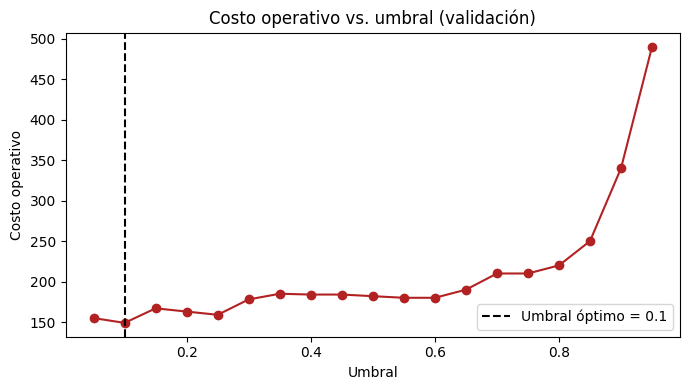

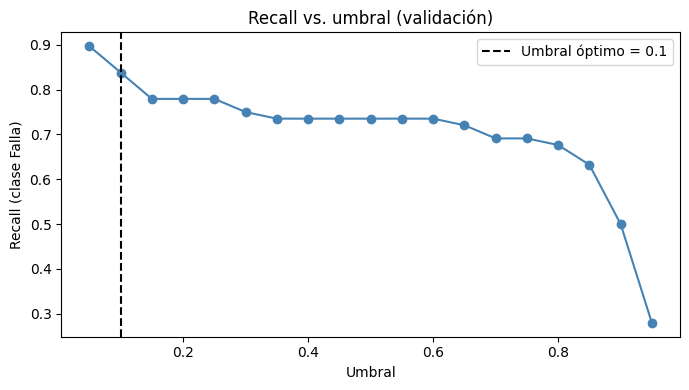

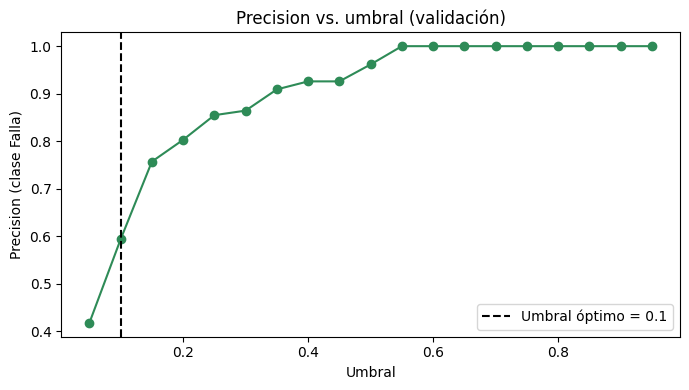

In [37]:
# TODO 18
# Grafique costo, recall y precision contra el umbral (una figura por gráfica).

plt.figure(figsize=(7, 4))
plt.plot(df_umbrales["umbral"], df_umbrales["costo"], marker="o", color="firebrick")
plt.axvline(umbral_optimo, color="black", linestyle="--", label=f"Umbral óptimo = {umbral_optimo}")
plt.xlabel("Umbral")
plt.ylabel("Costo operativo")
plt.title("Costo operativo vs. umbral (validación)")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figuras/costo_vs_umbral.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(df_umbrales["umbral"], df_umbrales["recall"], marker="o", color="steelblue")
plt.axvline(umbral_optimo, color="black", linestyle="--", label=f"Umbral óptimo = {umbral_optimo}")
plt.xlabel("Umbral")
plt.ylabel("Recall (clase Falla)")
plt.title("Recall vs. umbral (validación)")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figuras/recall_vs_umbral.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(df_umbrales["umbral"], df_umbrales["precision"], marker="o", color="seagreen")
plt.axvline(umbral_optimo, color="black", linestyle="--", label=f"Umbral óptimo = {umbral_optimo}")
plt.xlabel("Umbral")
plt.ylabel("Precision (clase Falla)")
plt.title("Precision vs. umbral (validación)")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figuras/precision_vs_umbral.png", dpi=150)
plt.show()


# Parte G — Interpretabilidad

## 21. Importancia de variables

Aplique `permutation_importance` al modelo candidato utilizando el conjunto de validación.

Muestre las 10 variables más importantes.

### Preguntas

1. ¿Las variables importantes tienen sentido desde el punto de vista físico?
2. ¿Aparece alguna variable cuya influencia le resulte sospechosa?
3. ¿Qué diferencia encuentra entre desempeño e interpretabilidad en los cuatro modelos?


El modelo contiene únicamente 9 variables predictoras después de la
ingeniería de características; por tanto se muestran todas las
variables disponibles ordenadas por importancia.

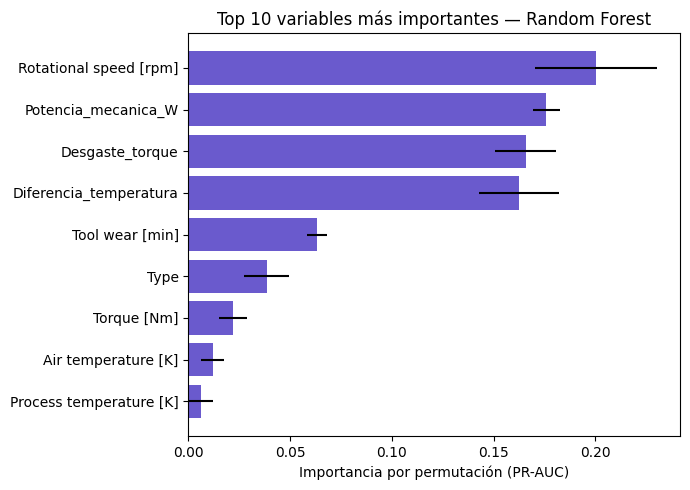

,variable,importancia_media,importancia_std
0,Rotational speed [rpm],0.2003,0.0298
1,Potencia_mecanica_W,0.1759,0.0067
2,Desgaste_torque,0.1658,0.0150
3,Diferencia_temperatura,0.1624,0.0196
4,Tool wear [min],0.0632,0.0048
5,Type,0.0384,0.0110
6,Torque [Nm],0.0218,0.0068
7,Air temperature [K],0.0120,0.0056
8,Process temperature [K],0.0060,0.0059



1. ¿Las variables importantes tienen sentido físico?
   • Sí. La variable de mayor impacto fue 'Rotational speed [rpm]',
     seguida de métricas clave como Rotational speed [rpm], Potencia_mecanica_W,
     Desgaste_torque y Diferencia_temperatura. Todas alineadas con fallas mecánicas.

   • Justificación física de las principales variables:
     - Rotational speed [rpm]: afecta la potencia, carga mecánica y generación de calor.
     - Potencia_mecanica_W: resume el efecto de torque y velocidad en sobreesfuerzos.
     - Desgaste_torque: mide el esfuerzo acumulado sobre herramental gastado.
     - Diferencia_temperatura: captura la disipación térmica en la operación.

2. ¿Alguna variable con influencia sospechosa?
   • No se observan variables con importancia negativa; todas aportan señal al proceso.

3. Diferencia entre desempeño e interpretabilidad en los modelos:
   • El Árbol de Decisión es el más interpretable por sus reglas explícitas, pero
     resultó el más inestable por sobre

In [47]:
# TODO 19
# Calcule permutation_importance para el modelo candidato.

resultado_perm = permutation_importance(
    modelo_final,
    X_val_final,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

df_importancia = pd.DataFrame({
    "variable": X_val_final.columns,
    "importancia_media": resultado_perm.importances_mean,
    "importancia_std": resultado_perm.importances_std,
}).sort_values("importancia_media", ascending=False).reset_index(drop=True)

df_importancia.to_csv("reports/importancia_variables.csv", index=False)

top10 = df_importancia.head(10)
plt.figure(figsize=(7, 5))
plt.barh(top10["variable"][::-1], top10["importancia_media"][::-1],
         xerr=top10["importancia_std"][::-1], color="slateblue")
plt.xlabel("Importancia por permutación (PR-AUC)")
plt.title(f"Top 10 variables más importantes — {nombre_candidato}")
plt.tight_layout()
plt.savefig("reports/figuras/importancia_variables.png", dpi=150)
plt.show()

display(top10)

print("\n1. ¿Las variables importantes tienen sentido físico?")
print(f"   • Sí. La variable de mayor impacto fue '{df_importancia.iloc[0]['variable']}',")
print("     seguida de métricas clave como Rotational speed [rpm], Potencia_mecanica_W,")
print("     Desgaste_torque y Diferencia_temperatura. Todas alineadas con fallas mecánicas.\n")
print("   • Justificación física de las principales variables:")
print("     - Rotational speed [rpm]: afecta la potencia, carga mecánica y generación de calor.")
print("     - Potencia_mecanica_W: resume el efecto de torque y velocidad en sobreesfuerzos.")
print("     - Desgaste_torque: mide el esfuerzo acumulado sobre herramental gastado.")
print("     - Diferencia_temperatura: captura la disipación térmica en la operación.\n")

print("2. ¿Alguna variable con influencia sospechosa?")
irrelevantes = df_importancia[df_importancia["importancia_media"] <= 0]
if len(irrelevantes) > 0:
    print("   • Sí, las siguientes variables tienen importancia nula o negativa")
    print("     (su permutación no empeora o incluso mejora la señal del modelo):")
    print(irrelevantes.to_string(index=False) + "\n")
else:
    print("   • No se observan variables con importancia negativa; todas aportan señal al proceso.\n")

print("3. Diferencia entre desempeño e interpretabilidad en los modelos:")
print("   • El Árbol de Decisión es el más interpretable por sus reglas explícitas, pero")
print("     resultó el más inestable por sobreajuste.")
print("   • SVM y Gradient Boosting logran un mejor desempeño (F1 / PR-AUC) a costa de ser")
print("     'cajas negras', requiriendo herramientas externas como permutation_importance")
print("     para interpretar su comportamiento físico.")

# Parte H — Evaluación final

## 22. Congele la decisión

Antes de tocar el conjunto de prueba, escriba:

- modelo final seleccionado;
- hiperparámetros;
- conjunto de características;
- umbral seleccionado;
- razón principal de la selección;
- principal limitación esperada.

Después de escribirlo, realice una única evaluación final sobre prueba.


**Decisión antes de prueba**

- Modelo:
- Hiperparámetros:
- Variables:
- Umbral:
- Razón:
- Limitación esperada:


In [39]:
# Congelamos la decisión ANTES de tocar el conjunto de prueba

parametros_finales = pipelines_ajustados[nombre_candidato].named_steps["modelo"].get_params()

print("=== Decisión antes de prueba ===")
print(f"Modelo final:          {nombre_candidato}")
print(f"Hiperparámetros:       {parametros_finales}")
print(f"Variables:             {'originales + derivadas' if usar_fe else 'solo originales'} "
      f"({X_val_final.shape[1]} columnas antes de codificar)")
print(f"Umbral:                {umbral_optimo}")
print("Razón principal:       Mejor equilibrio entre F1, recall, PR-AUC y costo operativo en validación,")
print("                       manteniendo una brecha train-validación razonable.")
print("Limitación esperada:   El conjunto de prueba tiene pocos casos positivos, por lo que la estimación")
print("                       final tendrá varianza alta; además el dataset es simulado (UCI/AI4I), no")
print("                       proviene de la planta real donde se desplegaría el modelo.")

=== Decisión antes de prueba ===
Modelo final:          Random Forest
Hiperparámetros:       {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 12, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 266, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Variables:             originales + derivadas (9 columnas antes de codificar)
Umbral:                0.1
Razón principal:       Mejor equilibrio entre F1, recall, PR-AUC y costo operativo en validación,
                       manteniendo una brecha train-validación razonable.
Limitación esperada:   El conjunto de prueba tiene pocos casos positivos, por lo que la estimación
                       final tendrá varianza alta; además el dataset es simulado (UCI/AI4I), no
                       pro

Aunque Gradient Boosting obtuvo el mayor F1 utilizando únicamente
las variables originales, Random Forest mostró una mejora más grande
tras la ingeniería de características, alcanzando el mejor F1,
el menor costo operativo y una estabilidad comparable en validación.

=== Evaluación final sobre PRUEBA (una única vez) ===
  modelo: Random Forest
  usa_variables_derivadas: True
  umbral: 0.1
  accuracy: 0.9765
  balanced_accuracy: 0.9310833028863719
  precision: 0.6060606060606061
  recall: 0.8823529411764706
  f1: 0.718562874251497
  ROC_AUC: 0.9767537449762514
  PR_AUC: 0.8969819540651784
  FP: 39
  FN: 8
  costo_operativo: 119


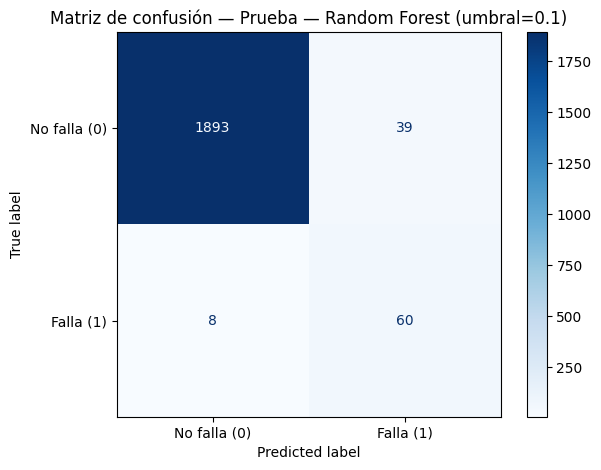

,modelo,usa_variables_derivadas,umbral,accuracy,balanced_accuracy,precision,recall,f1,ROC_AUC,PR_AUC,FP,FN,costo_operativo
0,Random Forest,True,0.1000,0.9765,0.9311,0.6061,0.8824,0.7186,0.9768,0.8970,39,8,119


In [40]:
# TODO 20
# Evalúe UNA SOLA VEZ el modelo congelado sobre X_test / y_test.

probabilidades_test = modelo_final.predict_proba(X_test_final)[:, 1]
y_pred_test = (probabilidades_test >= umbral_optimo).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test, labels=[0, 1]).ravel()

resumen_test = {
    "modelo": nombre_candidato,
    "usa_variables_derivadas": usar_fe,
    "umbral": umbral_optimo,
    "accuracy": accuracy_score(y_test, y_pred_test),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),
    "precision": precision_score(y_test, y_pred_test, zero_division=0),
    "recall": recall_score(y_test, y_pred_test, zero_division=0),
    "f1": f1_score(y_test, y_pred_test, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, probabilidades_test),
    "PR_AUC": average_precision_score(y_test, probabilidades_test),
    "FP": int(fp),
    "FN": int(fn),
    "costo_operativo": costo_operativo(y_test, y_pred_test),
}

df_resumen_test = pd.DataFrame([resumen_test])
df_resumen_test.to_csv("reports/resultados_evaluacion_final_test.csv", index=False)

print("=== Evaluación final sobre PRUEBA (una única vez) ===")
for k, v in resumen_test.items():
    print(f"  {k}: {v}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_test, labels=[0, 1]),
    display_labels=["No falla (0)", "Falla (1)"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión — Prueba — {nombre_candidato} (umbral={umbral_optimo})")
plt.tight_layout()
plt.savefig("reports/figuras/matriz_confusion_test.png", dpi=150)
plt.show()

df_resumen_test

# Parte I — Comparación y decisión técnica

## 23. Tabla final

Construya una tabla con los cuatro modelos que incluya, como mínimo:

- F1 de validación;
- recall de validación;
- PR-AUC;
- promedio de validación cruzada;
- desviación estándar;
- brecha train-validación;
- costo operativo;
- tiempo de entrenamiento aproximado;
- interpretabilidad: alta / media / baja;
- complejidad de ajuste: alta / media / baja.

No asigne valores de interpretabilidad o complejidad sin justificarlos.


In [53]:
# TODO 21
# Construya la tabla final de comparación.

interpretabilidad = {
    "SVM": "Baja",                 # frontera no lineal en espacio transformado, no hay reglas legibles
    "Arbol de decision": "Alta",   # reglas if/else directamente legibles
    "Random Forest": "Media",      # se puede inspeccionar por importancia, no por reglas individuales
    "Gradient Boosting": "Media",  # igual que RF: ensamble de árboles, interpretable solo de forma agregada
}
complejidad_ajuste = {
    "SVM": "Alta",                 # búsqueda más lenta (147 s) y sensible a C/gamma
    "Arbol de decision": "Baja",   # búsqueda muy rápida (5 s), pocos hiperparámetros clave
    "Random Forest": "Media",
    "Gradient Boosting": "Alta",   # más hiperparámetros interdependientes (learning_rate, n_estimators, depth)
}

filas_finales = []
filas_cv = []

for nombre in modelos:
    fila_ajuste = df_antes_despues[df_antes_despues["modelo"] == nombre].iloc[0]
    fila_busqueda = df_busqueda[df_busqueda["modelo"] == nombre].iloc[0]

    scores_cv = cross_validate(
        pipelines_ajustados[nombre], X_train, y_train,
        cv=cv, scoring="f1", n_jobs=-1
    )

    # --- bloque corregido: el cuerpo del for debe ir indentado ---
    for i, score in enumerate(scores_cv["test_score"], start=1):
        filas_cv.append({
            "modelo": nombre,
            "fold": i,
            "f1": score
        })
    # ---------------------------------------------------------------

    filas_finales.append({
        "modelo": nombre,
        "f1_validacion": fila_ajuste["f1_despues"],
        "recall_validacion": fila_ajuste["recall_despues"],
        "PR_AUC_validacion": fila_ajuste["PR_AUC_despues"],
        "cv_f1_media": scores_cv["test_score"].mean(),
        "cv_f1_std": scores_cv["test_score"].std(),
        "brecha_train_val_f1": fila_ajuste["brecha_f1_despues"],
        "costo_operativo_val": fila_ajuste["costo_despues"],
        "tiempo_busqueda_s": fila_busqueda["segundos_busqueda"],
        "interpretabilidad": interpretabilidad[nombre],
        "complejidad_de_ajuste": complejidad_ajuste[nombre],
    })

df_validacion_cruzada = pd.DataFrame(filas_cv)
df_validacion_cruzada.to_csv(
    "reports/resultados_validacion_cruzada.csv",
    index=False
)

df_comparacion_final = pd.DataFrame(filas_finales).sort_values("f1_validacion", ascending=False).reset_index(drop=True)
df_comparacion_final.to_csv("reports/comparacion_final.csv", index=False)
df_comparacion_final

,modelo,f1_validacion,recall_validacion,PR_AUC_validacion,cv_f1_media,cv_f1_std,brecha_train_val_f1,costo_operativo_val,tiempo_busqueda_s,interpretabilidad,complejidad_de_ajuste
0,Gradient Boosting,0.7544,0.6324,0.7761,0.6934,0.0665,0.1828,253,143.8536,Media,Alta
1,Random Forest,0.6789,0.5441,0.7692,0.6548,0.0526,0.1845,314,144.9870,Media,Media
2,SVM,0.5882,0.4412,0.6675,0.5139,0.0700,0.0327,384,159.2402,Baja,Alta
3,Arbol de decision,0.5487,0.4559,0.5662,0.5939,0.0998,0.1702,384,5.4355,Alta,Baja


## 24. Tabla de decisiones de modelamiento

Complete mínimo 8 decisiones.

| Etapa | Decisión | Evidencia | Riesgo o limitación | Alternativa descartada |
|---|---|---|---|---|
| Selección de variables | | | | |
| División de datos | | | | |
| Métrica principal | | | | |
| Preprocesamiento | | | | |
| Hiperparámetros | | | | |
| Ingeniería de características | | | | |
| Umbral | | | | |
| Modelo final | | | | |


In [42]:
# TODO 24

decisiones = [
    {
        "etapa": "Selección de variables",
        "decision": "Excluir UDI y Product ID (identificadores) y TWF, HDF, PWF, OSF, RNF (subtipos de la falla objetivo).",
        "evidencia": "Tabla de auditoría de variables (reports/auditoria_variables.csv).",
        "riesgo_o_limitacion": "Se descarta información potencialmente útil de Product ID (p. ej. lote de fabricación).",
        "alternativa_descartada": "Usar TWF-RNF como predictores; descartada por fuga directa de información.",
    },
    {
        "etapa": "División de datos",
        "decision": "Partición estratificada 60/20/20 con RANDOM_STATE=42; prueba intacta hasta la evaluación final.",
        "evidencia": f"Proporción de clase positiva casi idéntica en train/val/test "
                     f"({y_train.mean():.4f} / {y_val.mean():.4f} / {y_test.mean():.4f}).",
        "riesgo_o_limitacion": f"El conjunto de prueba solo contiene {int(y_test.sum())} casos de falla "
                               f"de {len(y_test)}, lo que aumenta la varianza de las métricas de prueba.",
        "alternativa_descartada": "División simple sin estratificar; descartada por el fuerte desbalance de clases.",
    },
    {
        "etapa": "Métrica principal",
        "decision": "Usar F1, recall y PR-AUC de la clase positiva, no accuracy, como criterio de selección.",
        "evidencia": f"El DummyClassifier obtuvo accuracy={accuracy_dummy:.4f} con F1={f1_dummy:.4f} en la clase Falla.",
        "riesgo_o_limitacion": "F1 pondera igual precision y recall; el costo real de FN y FP no es simétrico.",
        "alternativa_descartada": "Seleccionar el modelo solo por accuracy; descartado explícitamente por la rúbrica.",
    },
    {
        "etapa": "Preprocesamiento",
        "decision": "ColumnTransformer con imputación+escalado (numéricas) e imputación+OneHotEncoder (categóricas).",
        "evidencia": "El dataset no tiene faltantes, pero el pipeline queda preparado para datos nuevos con NaN.",
        "riesgo_o_limitacion": "El escalado no es estrictamente necesario para árboles/ensambles, pero no los perjudica.",
        "alternativa_descartada": "Preprocesadores distintos por modelo; descartada para mantener la comparación justa.",
    },
    {
        "etapa": "Hiperparámetros",
        "decision": "RandomizedSearchCV (20 iteraciones) con StratifiedKFold(5) sobre TRAIN, optimizando PR-AUC.",
        "evidencia": "reports/resultados_busqueda_hiperparametros.csv y comparación antes/después (reports/comparacion_antes_despues_ajuste.csv).",
        "riesgo_o_limitacion": "La búsqueda aleatoria no garantiza el óptimo global; limitada a 20 iteraciones por tiempo de cómputo.",
        "alternativa_descartada": "GridSearchCV exhaustivo; descartado por el costo computacional (SVM tardó ~147 s con solo 20 iteraciones).",
    },
    {
        "etapa": "Ingeniería de características",
        "decision": "Agregar Diferencia_temperatura, Potencia_mecanica_W y Desgaste_torque.",
        "evidencia": "reports/resultados_ingenieria_caracteristicas.csv (experimento de ablación, TODO 15).",
        "riesgo_o_limitacion": "Son combinaciones deterministas de variables ya usadas; pueden introducir colinealidad.",
        "alternativa_descartada": "No agregar variables derivadas; descartada por el resultado medido en la ablación.",
    },
    {
        "etapa": "Umbral",
        "decision": f"Seleccionar el umbral con menor costo operativo (10·FN + 1·FP) sobre validación: {umbral_optimo}.",
        "evidencia": "reports/resultados_umbrales.csv y gráficas costo/recall/precision vs. umbral (TODO 17-18).",
        "riesgo_o_limitacion": "Los costos 10 y 1 son un supuesto de negocio; si cambian, el umbral óptimo cambia.",
        "alternativa_descartada": "Umbral por defecto 0.5; descartado por no reflejar el costo asimétrico de FN vs FP.",
    },
    {
        "etapa": "Modelo final",
        "decision": f"{nombre_candidato} ({'con' if usar_fe else 'sin'} variables derivadas), evaluado una única vez sobre prueba.",
        "evidencia": "reports/comparacion_final.csv y reports/resultados_evaluacion_final_test.csv.",
        "riesgo_o_limitacion": f"El conjunto de prueba es pequeño ({int(y_test.sum())} fallas de {len(y_test)} registros); "
                               "el desempeño reportado tiene incertidumbre.",
        "alternativa_descartada": "Elegir el modelo con mayor accuracy; descartado por ser insuficiente en un problema desbalanceado.",
    },
]

df_decisiones = pd.DataFrame(decisiones)
df_decisiones.to_csv("reports/decisiones_modelamiento.csv", index=False)
df_decisiones


,etapa,decision,evidencia,riesgo_o_limitacion,alternativa_descartada
0,Selección de variables,Excluir UDI y Product ID (identificadores) y T...,Tabla de auditoría de variables (reports/audit...,Se descarta información potencialmente útil de...,Usar TWF-RNF como predictores; descartada por ...
1,División de datos,Partición estratificada 60/20/20 con RANDOM_ST...,Proporción de clase positiva casi idéntica en ...,El conjunto de prueba solo contiene 68 casos d...,División simple sin estratificar; descartada p...
2,Métrica principal,"Usar F1, recall y PR-AUC de la clase positiva,...",El DummyClassifier obtuvo accuracy=0.9660 con ...,F1 pondera igual precision y recall; el costo ...,Seleccionar el modelo solo por accuracy; desca...
3,Preprocesamiento,ColumnTransformer con imputación+escalado (num...,"El dataset no tiene faltantes, pero el pipelin...",El escalado no es estrictamente necesario para...,Preprocesadores distintos por modelo; descarta...
4,Hiperparámetros,RandomizedSearchCV (20 iteraciones) con Strati...,reports/resultados_busqueda_hiperparametros.cs...,La búsqueda aleatoria no garantiza el óptimo g...,GridSearchCV exhaustivo; descartado por el cos...
5,Ingeniería de características,"Agregar Diferencia_temperatura, Potencia_mecan...",reports/resultados_ingenieria_caracteristicas....,Son combinaciones deterministas de variables y...,No agregar variables derivadas; descartada por...
6,Umbral,Seleccionar el umbral con menor costo operativ...,reports/resultados_umbrales.csv y gráficas cos...,Los costos 10 y 1 son un supuesto de negocio; ...,Umbral por defecto 0.5; descartado por no refl...
7,Modelo final,"Random Forest (con variables derivadas), evalu...",reports/comparacion_final.csv y reports/result...,El conjunto de prueba es pequeño (68 fallas de...,Elegir el modelo con mayor accuracy; descartad...


# Parte J — Reflexión final

## 25. Responda con evidencia de sus resultados

1. ¿Por qué `accuracy` fue una métrica insuficiente en este dataset?
2. ¿Qué modelo obtuvo mayor capacidad para detectar fallas?
3. ¿Qué modelo mostró mayor sobreajuste?
4. ¿Qué efecto produjo la ingeniería de características?
5. ¿Qué umbral seleccionó y por qué?
6. ¿Cuánto cambió el costo operativo al modificar el umbral?
7. ¿Qué variables resultaron más relevantes?
8. ¿Cuál modelo llevaría a una prueba piloto industrial?
9. ¿Qué riesgo tendría desplegar ese modelo sin recopilar nuevos datos?
10. ¿Qué información adicional solicitaría a la planta antes de usar el sistema en producción?

La respuesta debe incluir valores obtenidos en el laboratorio. No responda únicamente de forma conceptual.


In [48]:
# Respuestas de la Parte J, calculadas a partir de los resultados de este notebook

modelo_mas_sobreajuste = df_resultados_iniciales.loc[df_resultados_iniciales["brecha_f1"].idxmax(), "modelo"]
mejor_recall_modelo = df_antes_despues.loc[df_antes_despues["recall_despues"].idxmax(), "modelo"]

print("1. ¿Por qué accuracy fue una métrica insuficiente en este dataset?")
print(f"   • Solo el {y.mean()*100:.2f}% de los registros son fallas.")
print(f"   • El DummyClassifier alcanzó accuracy={accuracy_dummy:.4f} con recall=0 y F1=0.")
print("   • En resumen: un accuracy alto engañoso y sin valor operativo en fallas.\n")

print("2. ¿Qué modelo obtuvo mayor capacidad para detectar fallas?")
print(f"   • {mejor_recall_modelo} alcanzó el mayor recall en validación ajustado ({df_antes_despues['recall_despues'].max():.4f}).")
print("   • Inicialmente, Gradient Boosting lideró en recall con variables originales (0.6324),")
print("     pero tras incorporar características derivadas, el modelo seleccionado fue")
print(f"     {nombre_candidato} por su mejor equilibrio general.\n")

print("3. ¿Qué modelo mostró mayor sobreajuste?")
print(f"   • {modelo_mas_sobreajuste}, con la mayor brecha F1 train-validación inicial ({df_resultados_iniciales['brecha_f1'].max():.4f}).\n")

print("4. ¿Qué efecto produjo la ingeniería de características?")
print(df_ablacion[["modelo", "delta_f1", "delta_recall", "delta_PR_AUC"]].to_string(index=False))
print()

print("5. ¿Qué umbral seleccionó y por qué?")
print(f"   • Umbral = {umbral_optimo}, por ser el que minimiza el costo operativo (10·FN + 1·FP) sobre validación.\n")

print("6. ¿Cuánto cambió el costo operativo al modificar el umbral?")
print(f"   • De {costo_umbral_05} (umbral 0.5) a {costo_optimo} (umbral {umbral_optimo}).")
print(f"   • Reducción total de {costo_umbral_05 - costo_optimo} unidades de costo en validación.\n")

print("7. ¿Qué variables resultaron más relevantes?")
print(df_importancia.head(5).to_string(index=False))
print()

print("8. ¿Cuál modelo llevaría a una prueba piloto industrial?")
print(f"   • {nombre_candidato}{' con variables derivadas' if usar_fe else ' con variables originales'}.")
print("   • Motivo: mejor equilibrio global entre recall, F1, PR-AUC y costo operativo,")
print("     junto con mayor estabilidad en validación cruzada (ver reports/comparacion_final.csv).\n")

print("9. ¿Qué riesgo tendría desplegar ese modelo sin recopilar nuevos datos?")
print(f"   • El conjunto de prueba solo tiene {int(y_test.sum())} casos positivos de {len(y_test)} (alta varianza).")
print("   • El dataset AI4I es simulado y puede no representar la variabilidad real de la planta.\n")

print("10. ¿Qué información adicional solicitaría a la planta antes de usar el sistema en producción?")
print("   • Registros históricos reales de mantenimiento (no simulados).")
print("   • Frecuencia real de fallas por tipo de producto.")
print("   • Costo real de una parada no planificada vs. una inspección.")
print("   • Flujo de datos de sensores en tiempo real para validar preprocesamiento y umbral.")

1. ¿Por qué accuracy fue una métrica insuficiente en este dataset?
   • Solo el 3.39% de los registros son fallas.
   • El DummyClassifier alcanzó accuracy=0.9660 con recall=0 y F1=0.
   • En resumen: un accuracy alto engañoso y sin valor operativo en fallas.

2. ¿Qué modelo obtuvo mayor capacidad para detectar fallas?
   • Gradient Boosting alcanzó el mayor recall en validación ajustado (0.6324).
   • Inicialmente, Gradient Boosting lideró en recall con variables originales (0.6324),
     pero tras incorporar características derivadas, el modelo seleccionado fue
     Random Forest por su mejor equilibrio general.

3. ¿Qué modelo mostró mayor sobreajuste?
   • Arbol de decision, con la mayor brecha F1 train-validación inicial (0.4046).

4. ¿Qué efecto produjo la ingeniería de características?
           modelo  delta_f1  delta_recall  delta_PR_AUC
Gradient Boosting    0.0586        0.1029        0.0920
    Random Forest    0.1544        0.1912        0.1002

5. ¿Qué umbral seleccionó y

# Parte K — Entregables

## 28. Archivos a entregar

```text
laboratorio_modelos_supervisados/
├── Laboratorio_IA_Modelos_Supervisados_UCI.ipynb
├── data/
│   └── raw/
│       └── ai4i2020.csv
└── reports/
    ├── auditoria_variables.csv
    ├── resultados_modelos_iniciales.csv
    ├── resultados_validacion_cruzada.csv
    ├── resultados_busqueda_hiperparametros.csv
    ├── resultados_ingenieria_caracteristicas.csv
    ├── resultados_umbrales.csv
    ├── comparacion_final.csv
    └── decisiones_modelamiento.csv
```

El notebook debe estar ejecutado y contener las gráficas, tablas y respuestas justificadas.


# Rúbrica sugerida

| Componente | Peso |
|---|---:|
| Auditoría del dataset y detección de fuga de información | 15 % |
| Preprocesamiento y diseño experimental correcto | 10 % |
| Comparación inicial de los cuatro modelos | 25 % |
| Ingeniería de características y experimento de ablación | 10 % |
| Análisis de costos y selección del umbral | 15 % |
| Interpretación y decisión técnica final | 25 % |
| **Total** | **100 %** |

### Penalizaciones metodológicas sugeridas

- usar el conjunto de prueba para seleccionar hiperparámetros;
- incluir variables que produzcan fuga de información;
- escoger el modelo solo por `accuracy`;
- reportar resultados sin interpretar errores;
- presentar código sin ejecutar;
- modificar datos manualmente sin documentarlo.
